In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [17]:
batch_size = 8
gpu = "NVIDIA A100 80GB"
lengths = [2, 3, 4, 5, 6, 7, 8, 9]
static_vram = [
    #    2,      3,      4,      5,      6,      7,      8,      9,
    # 30.891, 31.030, 31.172, 31.340, 31.497, 31.645, 31.805, 31.979, # 16
    18.397, 18.438, 18.514, 18.612, 18.690, 18.774, 18.872, 18.956  # 8 (ORIG)
    # 16.986, 00.000, 00.000, 17.150, 00.000, 00.000, 17.437, 00.000  # 8
    # 16.986, 17.040, 17.095, 17.150, 17.204, 17.259, 17.437, 17.492  # 8 (projected)
]
recurrent_vram = [
    #    2,      3,      4,      5,      6,      7,      8,      9,
    #    2,      3,      4,    OOM,    OOM,    OOM,    OOM,    OOM,
    # 49.266, 65.688, 78.124, 00.000, 00.000, 00.000, 00.000, 00.000, # 16
    27.754, 36.143, 44.557, 52.913, 61.303, 69.704, 78.100, 86.490  # 8  (ORIG)
    # 00.000, 00.000, 00.000, 51.466, 00.000, 00.000, 76.697, 00.000, # 8
]
lidar_vram = [
    #    2,      3,      4,      5,      6,      7,      8,      9,
    17.161, 18.825, 18.831, 20.890, 20.849, 23.165, 23.116, 26.154  # 8  (ORIG)
]
default_tfpp = 16.736

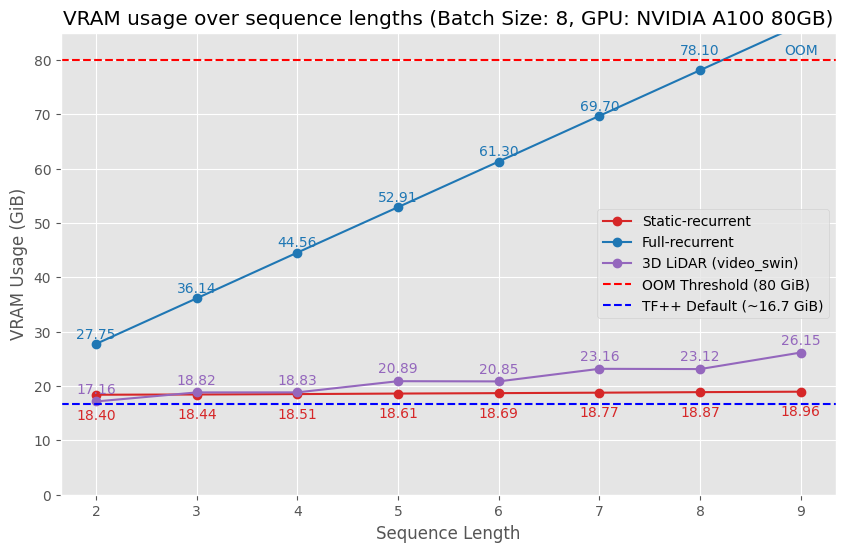

In [20]:
# Plot VRAM for both static and recurrent across different lengths
plt.figure(figsize=(10, 6))
plt.plot(lengths, static_vram, label="Static-recurrent", marker="o", color="tab:red")
plt.plot(lengths, recurrent_vram, label="Full-recurrent", marker="o", color="tab:blue")
plt.plot(lengths, lidar_vram, label="3D LiDAR (video_swin)", marker="o", color="tab:purple")

# Add text above each point
for i, vram in enumerate(static_vram):
    plt.text(lengths[i], vram - 5, f"{vram:.2f}", ha="center", va="bottom", color="tab:red")
for i, vram in enumerate(lidar_vram):
    plt.text(lengths[i], vram + 1.0, f"{vram:.2f}", ha="center", va="bottom", color="tab:purple")
for i, vram in enumerate(recurrent_vram):
    if vram > 80:
        plt.text(lengths[i], 80 + 0.5, "OOM", ha="center", va="bottom", color="tab:blue")
    else:
        plt.text(lengths[i], (vram if vram<78 else 80) + 0.5, f"{vram:.2f}", ha="center", va="bottom", color="tab:blue")
plt.xlabel("Sequence Length")
plt.ylabel("VRAM Usage (GiB)")
plt.title(f"VRAM usage over sequence lengths (Batch Size: {batch_size}, GPU: {gpu})")
plt.xticks(lengths)
plt.legend()


# Set plot style
plt.style.use("ggplot")
# Plot VRAM usage
# plot_vram(lengths, static_vram, recurrent_vram)
# Add light red line for OOM at 80 gig
plt.axhline(y=80, color="red", linestyle="--", label="OOM Threshold (80 GiB)")
plt.axhline(y=default_tfpp, color="blue", linestyle="--", label="TF++ Default (~16.7 GiB)")
plt.ylim(0, 85)
plt.legend()
plt.show()


In [14]:
batch_size = 8
epochs = 5
gpu = "NVIDIA H100 80GB"
lengths = [2, 5, 8]
#                         2,      3,      4,      5,      6,      7,      8,      9,
# static_runtime    = [37.200, 00.000, 00.000, 68.856, 00.000, 00.000, 00.000, 00.000]
# recurrent_runtime = [31.272, 00.000, 00.000, 00.000, 00.000, 00.000, 00.000, 00.000]
#                         2,    5,     8,     9,
static_runtime    = [01.52, 02.73, 03.97] #19.54]
recurrent_runtime = [01.97, 04.58, 07.18] #00.00]
lidar_runtime     = [01.22, 01.42, 01.50] #04.19] # 4.22 is projected
# mm:ss
# default_tfpp = 05.14
default_tfpp = 01.35 # 04.97
# dataset size = 5114 / 174356 = ~3%

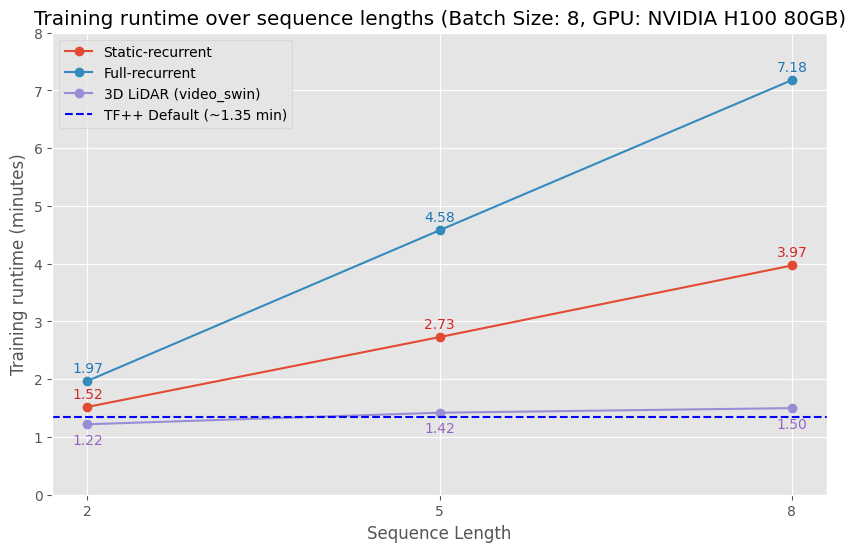

In [15]:
# Plot VRAM for both static and recurrent across different lengths
plt.figure(figsize=(10, 6))
plt.plot(lengths, static_runtime, label="Static-recurrent", marker="o")
plt.plot(lengths, recurrent_runtime, label="Full-recurrent", marker="o")
plt.plot(lengths, lidar_runtime, label="3D LiDAR (video_swin)", marker="o")

# Add text above each point
for i, vram in enumerate(static_runtime):
    plt.text(lengths[i], vram + 0.1, f"{vram:.2f}", ha="center", va="bottom", color="tab:red")
for i, vram in enumerate(lidar_runtime):
    plt.text(lengths[i], vram - 0.4, f"{vram:.2f}", ha="center", va="bottom", color="tab:purple")
for i, vram in enumerate(recurrent_runtime):
    plt.text(lengths[i], vram + 0.1, f"{vram:.2f}", ha="center", va="bottom", color="tab:blue")
plt.xlabel("Sequence Length")
plt.ylabel("Training runtime (minutes)")
plt.title(f"Training runtime over sequence lengths (Batch Size: {batch_size}, GPU: {gpu})")
plt.xticks(lengths)
plt.legend()


# Set plot style
plt.style.use("ggplot")
# Plot VRAM usage
# plot_vram(lengths, static_vram, recurrent_vram)
# Add light red line for OOM at 80 gig
plt.axhline(y=default_tfpp, color="blue", linestyle="--", label=f"TF++ Default (~{default_tfpp} min)")
plt.ylim(0, 8)
plt.legend()
plt.show()